In [1]:
import pandas as pd
import numpy as np
from chains import LinRegMC
from evaluate_results import Evaluator
from itertools import product
from state import State,StateValidator
from transition_fn import t_table_gen_by_lin_reg
NUM_BINS = 10 # This is the number of bins for parameters, not the number of bins for classification

/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


In [2]:
#Creating the parameter ranges for each param
num_bins_range = list(range(3,8,2))
window_len_range = list(range(2,7))
state_width_range = np.linspace(0.1,3,NUM_BINS)


p_matrices = [[None]*(3+2*NUM_BINS) for _ in range(2+NUM_BINS)] # first index is the window_len, second index is num_bins
# len(list(product(num_bins_range,window_len_range,state_width_range)))

In [ ]:
import concurrent.futures
import pathlib

def process_matrix(args):
    num_bin, window_len = args
    print(num_bin, window_len)
    path = pathlib.Path(f"./data/lin_reg_pmats/{window_len}-{num_bin}.csv")
    if path.exists():
        return
    val = StateValidator(num_bin, window_len)
    p_matrix = t_table_gen_by_lin_reg(val)
    p_matrix.to_csv(f"./data/lin_reg_pmats/{window_len}-{num_bin}.csv")

with concurrent.futures.ProcessPoolExecutor() as executor:
    executor.map(process_matrix, product(num_bins_range, window_len_range))




In [5]:
import pathlib
for file in pathlib.Path("./data/lin_reg_pmats").iterdir():
    window_len = int(file.name[0])
    df = pd.read_csv(file, index_col=list(range(window_len)), header=list(range(window_len)))
    print(df)
    break

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [7]:
bruh = pd.read_csv("./data/lin_reg_pmats/2-3.csv", index_col=list(range(2)), header=list(range(2)))
x = bruh.loc[(0,0)].shape
x

(9,)

In [5]:

window_len = 2
num_bins = 3
p_matrix = pd.read_csv(f"./data/lin_reg_pmats/{window_len}-{num_bins}.csv",index_col=list(range(num_bins)),header=list(range(num_bins-1)))
p_matrix.loc[(0, 0.1)].T[0].sum()

# len(p_matrix.loc[(0,0)].shape)



KeyError: 0.1

In [3]:
def instantiate_and_test(data:pd.Series,window_len:int,num_bins:int,state_width:float)->pd.Series:
    p_matrix = pd.read_csv(f"./data/lin_reg_pmats/{window_len}-{num_bins}.csv",index_col=list(range(num_bins)),header=list(range(num_bins)))
    mc = LinRegMC(data,window_len,num_bins,p_matrix, data.mean(),data.std(),state_width,)
    ev = Evaluator(data,mc.validator)
    perc_correct = ev.get_perc_correct(mc,100)

    return pd.Series([perc_correct,window_len,num_bins,state_width],index=["percent_correct","window_len","num_bins","state_width"])

In [4]:
import concurrent
df = pd.read_csv("./data/inflation_adjusted_berkshire_stocks.csv")
data = df["Open_adjusted"].diff().dropna()
param_generator = product(window_len_range,num_bins_range,state_width_range)

def worker(args):
    wl, nb, sw = args
    # print(f"Working on ({wl}, {nb}, {sw}")
    return instantiate_and_test(data, wl, nb, sw)

rows_list = []
with concurrent.futures.ProcessPoolExecutor() as executor:
    rows_list = list(executor.map(worker, param_generator))

results = pd.DataFrame(rows_list, columns=["percent_correct", "window_len", "num_bins", "state_width"])
results


IndexingError: Too many indexers

In [3]:
window_len = 5
num_bins = 5
p_mat = pd.read_csv(f"./data/lin_reg_pmats/{window_len}-{num_bins}.csv",index_col=list(range(num_bins)),header=list(range(num_bins)))
p_mat.index.size

2400

In [4]:
df = pd.read_csv("./data/inflation_adjusted_berkshire_stocks.csv")
data = df["Open_adjusted"].diff().dropna()
mc = LinRegMC(data,window_len,num_bins,p_mat,data.mean(),data.std(),0.5)
ev = Evaluator(data,mc.validator)

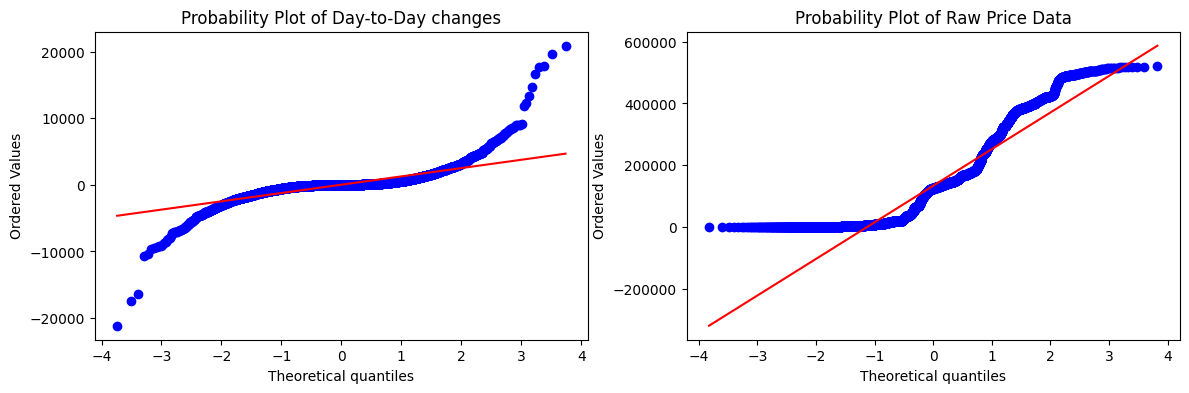

In [64]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
f,(ax1,ax2)= plt.subplots(1,2)
probplot(data[:7500],plot=ax1)
ax1.set_title("Probability Plot of Day-to-Day changes")
probplot(df["Open_adjusted"],plot=ax2)
ax2.set_title("Probability Plot of Raw Price Data")
f.set_size_inches(14,4)


Text(0.5, 1.0, 'Probability Plot of Raw Price Data')

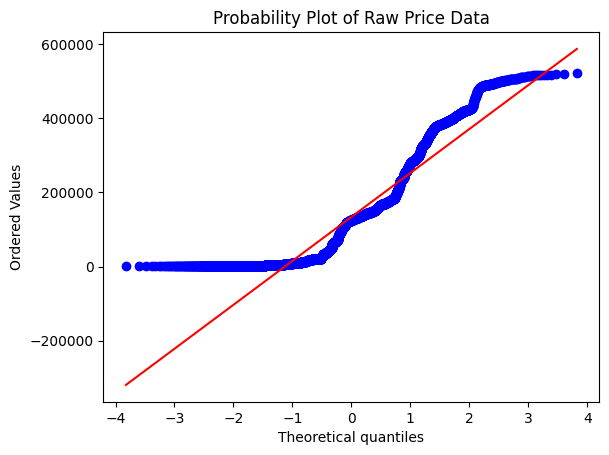

In [59]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
ax = plt.subplot()
probplot(df["Open_adjusted"],plot=ax)
ax.set_title("Probability Plot of Raw Price Data")

In [5]:
res = ev.evaluate_as_df(mc,7500)
# ev.get_perc_correct(mc,1000)

In [6]:
res["is_prediction_correct"].sum()/ res["is_prediction_correct"].count()

np.float64(0.8718666666666667)

In [7]:
import matplotlib.pyplot as plt
predicted_states = res["predicted_state"].apply(lambda x: x[-1])
predicted_states.value_counts()
predicted_states_freqs = predicted_states.value_counts() / predicted_states.count()
# plt.pie(predicted_state_freqs,labels=predicted_state_freqs.index)

In [8]:
actual_states = res["actual_state"].apply(lambda x: x[-1])
actual_states_freq = actual_states.value_counts() / actual_states.count()

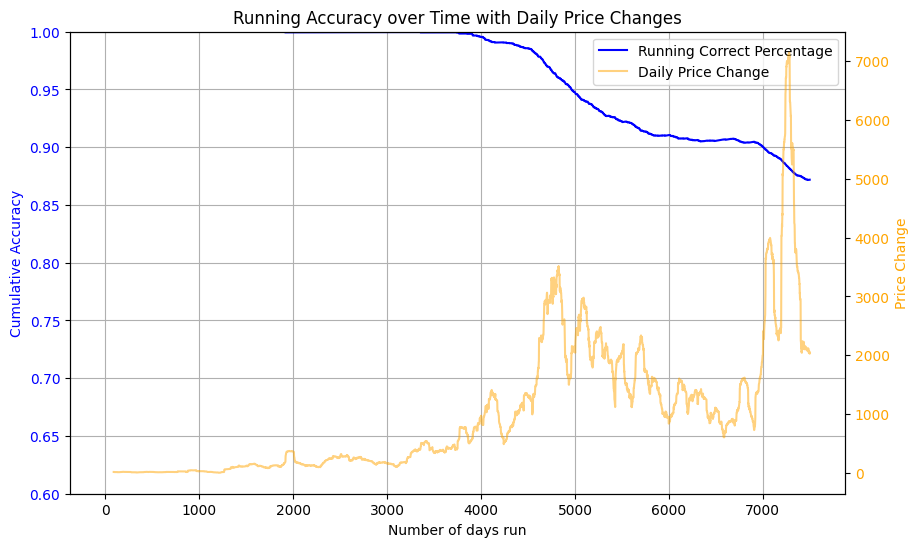

In [22]:
# Calculate the running correct percentage using a cumulative average
running_percentage = res['is_prediction_correct'].expanding().mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot running percentage on the left y-axis
ax1.plot(running_percentage.index, running_percentage, label='Running Correct Percentage', color='blue')
ax1.set_xlabel('Number of days run')
ax1.set_ylabel('Cumulative Accuracy', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0.6, 1)
ax1.grid(True)
ax1.set_title('Running Accuracy over Time with Daily Price Changes')

# Overlay the price changes on a secondary y-axis (right side)
ax2 = ax1.twinx()
graphed_data = data[:7500]
ax2.plot(graphed_data.index, graphed_data.rolling(90).std(), label='Daily Price Change', color='orange', alpha=0.5)
ax2.set_ylabel('Price Change', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

74.07925593336358


Text(0.5, 1.0, 'Accuracy vs. Standard Deviation')

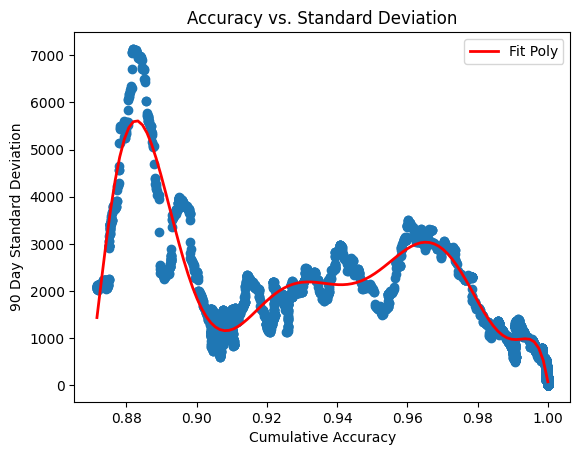

In [54]:
running_std = graphed_data.rolling(90).std()

common_idx = running_percentage.dropna().index.intersection(running_std.dropna().index)
x_clean = running_percentage.loc[common_idx]
y_clean = running_std.loc[common_idx]

fit_poly = np.polynomial.polynomial.Polynomial.fit(x_clean, y_clean, deg=10)
x_fit = np.linspace(running_percentage.min(), running_percentage.max(), 100)
y_fit = fit_poly(x_fit)
print(fit_poly(1))
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fit Poly')
plt.legend()

plt.scatter(running_percentage, running_std)
plt.xlabel("Cumulative Accuracy")
plt.ylabel("90 Day Standard Deviation")
plt.title("Accuracy vs. Standard Deviation")

Text(0.5, 1.0, 'Accuracy vs. Mean')

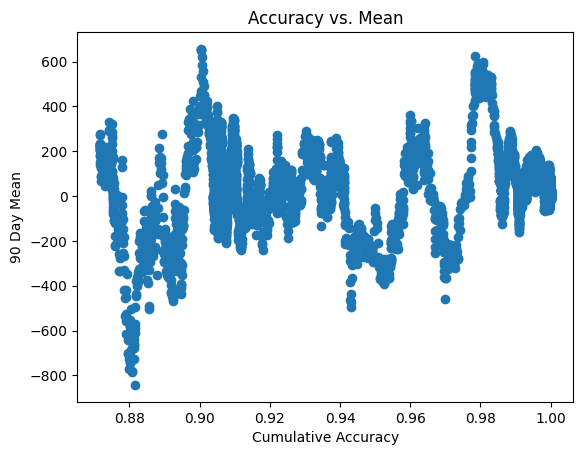

In [35]:
running_mean= graphed_data.rolling(90).mean()
plt.scatter(running_percentage,running_mean)
plt.xlabel("Cumulative Accuracy")
plt.ylabel("90 Day Mean")
plt.title("Accuracy vs. Mean")

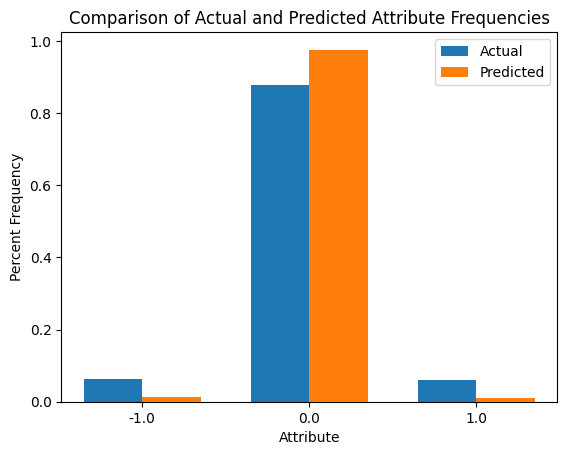

In [98]:
# Get the sorted list of states from both frequency series
states = sorted(set(predicted_states_freqs.index.astype(float)).union(set(actual_states_freq.index.astype(float))))

# Create positions for bars
x = np.arange(len(states))
width = 0.35

fig, ax = plt.subplots()

# Get the frequencies, using 0 for missing states
actual_counts = [actual_states_freq.get(state, 0) for state in states]
pred_counts = [predicted_states_freqs.get(state, 0) for state in states]

# Plot the bars
ax.bar(x - width/2, actual_counts, width, label='Actual')
ax.bar(x + width/2, pred_counts, width, label='Predicted')

ax.set_xlabel('Attribute')
ax.set_ylabel('Percent Frequency')
ax.set_title('Comparison of Actual and Predicted Attribute Frequencies')
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend()

plt.show()

In [108]:
res["is_prediction_correct"].count()

np.int64(7500)

/tmp/ipykernel_58663/664095268.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = conf_matrix.applymap(lambda x: f"{x}\n({x-avg:+.1f})\n{((x-avg)/std):+.1f} z")


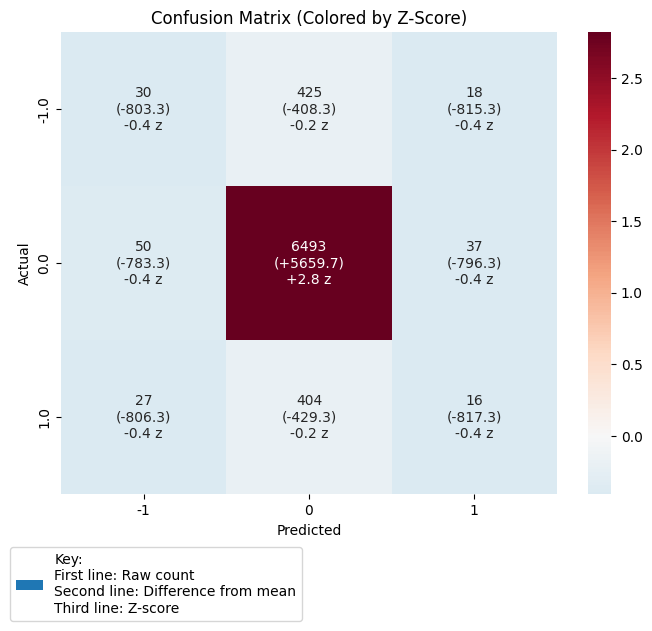

In [121]:
import seaborn as sns

# Extract the final state from each tuple
res['actual_final'] = res['actual_state'].apply(lambda x: x[-1])
res['predicted_final'] = res['predicted_state'].apply(lambda x: x[-1])

# Create a confusion matrix using pandas crosstab
conf_matrix = pd.crosstab(res['actual_final'], res['predicted_final'], rownames=['Actual'], colnames=['Predicted'])
avg = conf_matrix.values.mean()
std = conf_matrix.values.std()

# Create annotations that include:
# - the cell value,
# - its difference from the average,
# - and its z-score (in std deviations)
annot = conf_matrix.applymap(lambda x: f"{x}\n({x-avg:+.1f})\n{((x-avg)/std):+.1f} z")

# Compute the z-score matrix to use for coloring
z_matrix = (conf_matrix - avg) / std

plt.figure(figsize=(8, 6))
# Use a diverging colormap centered at zero so that cells are colored by their z-scores
sns.heatmap(z_matrix, annot=annot, fmt="", cmap="RdBu_r", center=0)
plt.title("Confusion Matrix (Colored by Z-Score)")
import matplotlib.patches as mpatches
legend_text = "Key:\nFirst line: Raw count\nSecond line: Difference from mean\nThird line: Z-score"
patch = mpatches.Patch(label=legend_text)
plt.legend(handles=[patch], loc='upper right', bbox_to_anchor=(0.5, -0.1), fontsize=10)
plt.show()

In [67]:
res.to_csv("./data/results/linreg-results.csv")